# Overfitting single intervals

## imports

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

PAL_MODALITIES = {
    "rna_seq": "#717EC3",
    "splice_site": "#AE8799",
    "splice_usage": "#C95D63",
    "splice_junctions": "#EE8434"
}

MAP_MODALITIES = {
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_pearson_r":"splice_junctions"
}

OUTPUT_DIR = os.path.join("pdfs","overfitting_single")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## data

In [2]:
# paths

ROOT = ".."
OUTPUT_DIR = os.path.join(ROOT,"results/finetuning/alphagenome_pytorch/overfitting/single")

logs_file = os.path.join(OUTPUT_DIR, "summary", "epoch_logs.parquet")

In [3]:
# loads

logs = pd.read_parquet(logs_file)

## figures

In [4]:
logs.value_counts(["density","run_name"])

density  run_name                                                         
medium   original__all                                                        50
         original__rna_seq_only                                               50
         original__splice_site_only                                           50
         original__splice_usage_only                                          50
         original__splice_junctions_only                                      50
         debug_splice_sites__randinit_noseg_gtf__all                          50
         debug_splice_sites__randinit_seg_gtf__all                            50
         debug_splice_sites__randinit_seg_nogtf__all                          50
         debug_splice_sites__pretrinit_seg_nogtf__all                         50
         debug_splice_sites__pretrinit_seg_gtf__all                           50
         debug_splice_sites__pretrinit_noseg_gtf__all                         50
         debug_splice_junctions__a

### splice site and junction heads struggle to overfit a single interval

In [5]:
X = logs.query("run_name=='original__all' & density=='medium'")

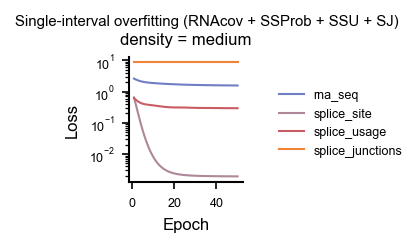

In [6]:
x = (
    X[
        ["epoch","density","val_loss_rna_seq_loss","val_loss_splice_site_loss","val_loss_splice_usage_loss","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="modality", palette=PAL_MODALITIES,
    col="density",
    linewidth=1,
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()

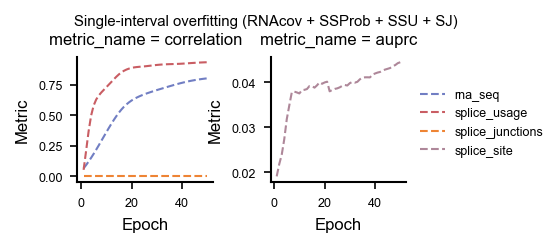

In [7]:
x = pd.concat([
    (
        X[
            ["epoch","density","rna_seq_1bp_profile_pearson_r_mean","splice_usage_pearson_r","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density"], var_name="modality", value_name="metric_value")
        .assign(metric_name="correlation")
    ),
    (
        X[
            ["epoch","density","splice_site_auprc_macro"]#,"splice_site_auprc_acceptor_pos","splice_site_auprc_acceptor_pos","splice_site_auprc_donor_neg","splice_site_auprc_acceptor_neg"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map({
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_pearson_r":"splice_junctions"
})
x = x.query("density=='medium'")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="modality", palette=PAL_MODALITIES,
    col="metric_name",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Metric"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()

### overfitting of splice site head is not influenced by other heads

In [8]:
X = logs.query("run_name.isin(['original__splice_site_only','original__all']) & density=='medium'")

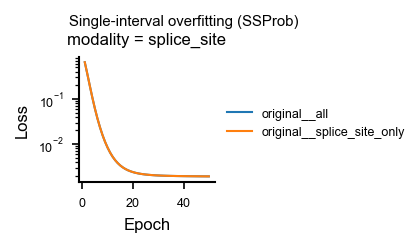

In [9]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_site_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name",
    col="modality",
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.1
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

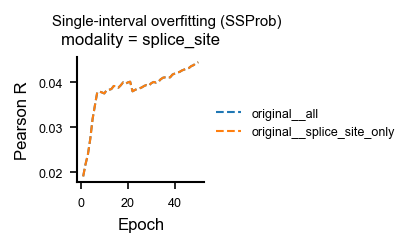

In [10]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_site_auprc_macro"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name",
    col="modality",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Pearson R"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

### splice site head is not influenced by segmentation or lack of annotated splice sites

In [11]:
X = logs.query("run_name.isin(['debug_splice_sites__randinit_seg_nogtf__all','debug_splice_sites__randinit_noseg_gtf__all','debug_splice_sites__randinit_seg_gtf__all','original__all']) & density=='medium'")

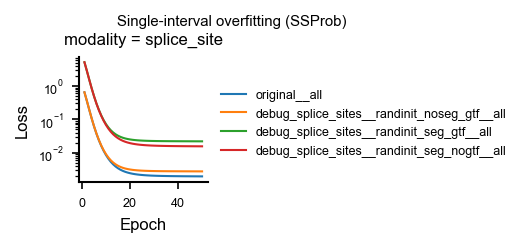

In [12]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_site_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name",
    col="modality",
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.1
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

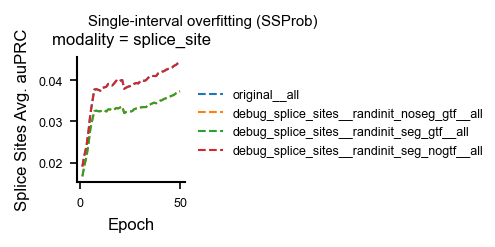

In [13]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_site_auprc_macro"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name",
    col="modality",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Splice Sites Avg. auPRC"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

### pretrained splice site head is influenced by segmentation and lack of annotated splice sites

In [14]:
X = logs.query("run_name.isin(['debug_splice_sites__pretrinit_seg_nogtf__all','debug_splice_sites__pretrinit_noseg_gtf__all','debug_splice_sites__pretrinit_seg_gtf__all','original__all']) & density=='medium'")

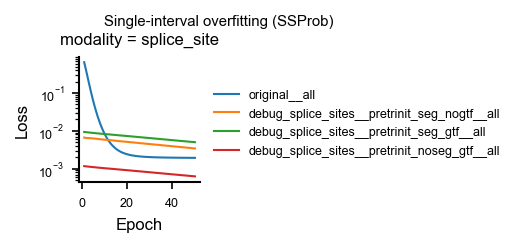

In [15]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_site_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name",
    col="modality",
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

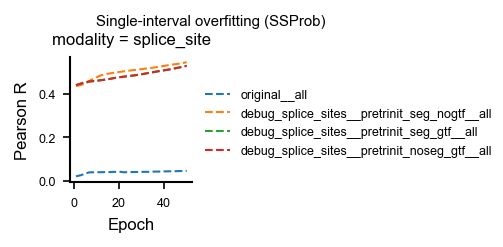

In [16]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_site_auprc_macro"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name",
    col="modality",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Pearson R"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SSProb)")

plt.show()

### overfitting of splice junction head is not influenced by other heads

In [17]:
X = logs.query("run_name.isin(['original__splice_junctions_only','original__all']) & density=='medium'")

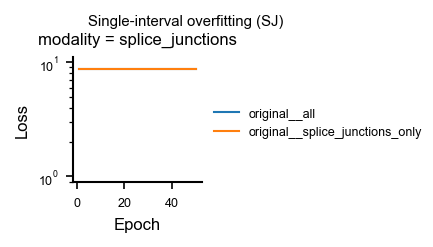

In [18]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name",
    col="modality",
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.1
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

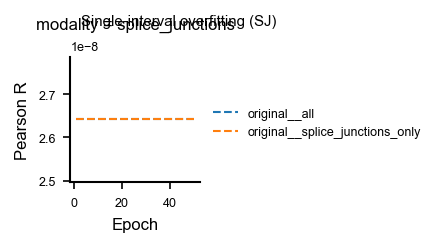

In [19]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name",
    col="modality",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=1.15
)

g.set(
    xlabel="Epoch",
    ylabel="Pearson R"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

### splice junction head is affected by rope initialization

In [20]:
runs_oi = [
    "debug_splice_junctions__annotated__origrope__origloss__all",
    "debug_splice_junctions__annotated__truncrope__origloss__all",
    "debug_splice_junctions__predicted__origrope_nogtf__origloss__all",
]
X = logs[logs["run_name"].isin(runs_oi)].copy()

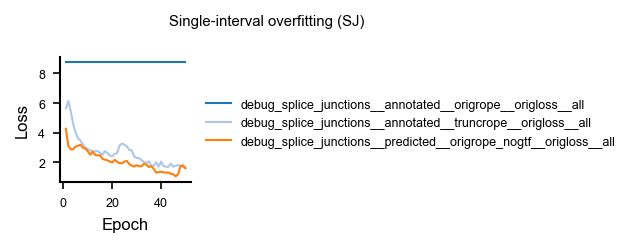

In [21]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)
x["is_truncrope"] = x["run_name"].str.contains("truncrope")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name", palette="tab20",
    linewidth=1,
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=1.2
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="linear",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

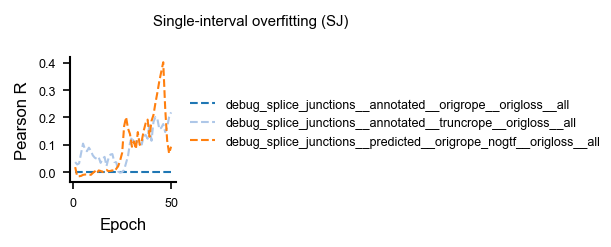

In [22]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)
x["is_truncrope"] = x["run_name"].str.contains("truncrope")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name", palette="tab20",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=1.2
)

g.set(
    xlabel="Epoch",
    ylabel="Pearson R"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

### splice junction head is affected by handling sparsity

In [23]:
runs_oi = [
    "debug_splice_junctions__annotated__truncrope__origloss__all",
    "debug_splice_junctions__annotated__truncrope__newloss__all",
    "debug_splice_junctions__predicted__origrope_nogtf__origloss__all",
    "debug_splice_junctions__predicted__origrope_nogtf__newloss__all",
]
X = logs[logs["run_name"].isin(runs_oi)].copy()

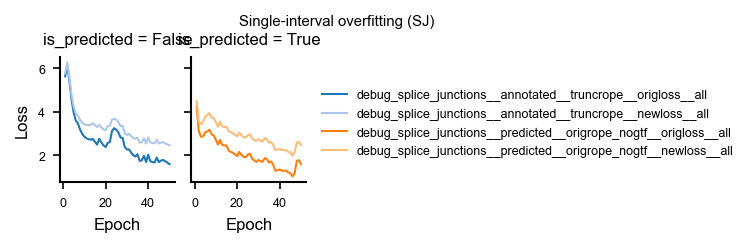

In [24]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)
x["is_predicted"] = x["run_name"].str.contains("predicted")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name", palette="tab20",
    col="is_predicted",
    linewidth=1,
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=0.8
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="linear",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJ)")

plt.show()

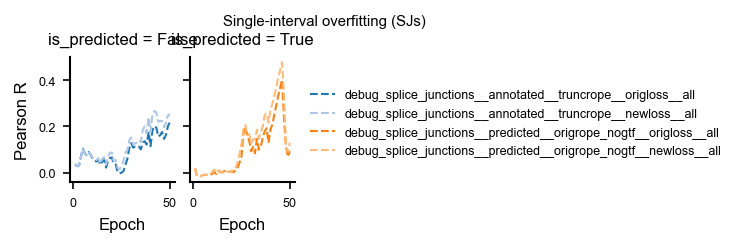

In [25]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map(MAP_MODALITIES)
x["is_predicted"] = x["run_name"].str.contains("predicted")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name", palette="tab20",
    col="is_predicted",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=True),
    height=4*cm, aspect=0.8
)

g.set(
    xlabel="Epoch",
    ylabel="Pearson R"
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (SJs)")

plt.show()